---
tags: [algorithm, finance, simulation]
---

# 量子コンピュータを用いたオプションプライシング

ゲート型量子コンピュータ上で実行する量子振幅推定は、様々な応用が提案されています。
その中でも、金融工学のオプションプライシングは、その最たる例です。
これまで、オプションプライシングには古典モンテカルロ法が用いられてきましたが、量子振幅推定はそれと比較して2次高速化をもたらすことが知られています。
そこで本記事では、[Stamatopoulos et al. (2020)](https://quantum-journal.org/papers/q-2020-07-06-291/)で提案された、量子振幅推定によるオプションおよびオプションポートフォリオプライシング手法の理解と実装についてまとめました。オプションプライシングの例を通して、Qamomileの使い方を学びましょう。

In [2]:
# Install the latest Qamomile through pip! 
# !pip install qamomile

In [3]:
import numpy as np
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

import qamomile.circuit as qmc
from qamomile.circuit.algorithm.state_preparation import amplitude_encoding
from qamomile.qiskit import QiskitTranspiler

## 背景

### 問題: オプションプライシング

金融リスクの計算は、大きな需要があります。
モンテカルロ (MC) 計算はその中心的な計算手法ですあり、Value at Risk (VaR) の推定や店頭デリバティブのプライシング決定など、幅広く用いられています。
しかし収束が悪く、その誤差は $\varepsilon = \mathcal{O} (M^{-1/2})$ で減衰するという欠点があります。
ここで $M$ はサンプル数です。  
対象となる確率分布が量子状態として準備される場合、量子振幅推定 (QAE) により、期待値などの統計量を $\mathcal{O} (M^{-1})$ で推定できることが知られています。
これは先ほどの古典MCに対し、二次の高速化をもたらすことがわかります。  
[Stamatopoulos et al. (2020)](https://quantum-journal.org/papers/q-2020-07-06-291/)では、先行研究のプライシング手法を拡張し、NISQ実機での計算を可能にする量子回路実装を示しました。

### 先行研究

モンテカルロプライシングの量子アルゴリズムの理論的枠組みを示した先行研究として、[Rebentrost et al. (2018)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.022321)があります。
この論文は、プライシング計算において、古典に対し2次高速化が得られることを理論的に示しました。
そして、特にヨーロピアンオプションとアジアンオプションに対して数値シミュレーションを行い、その有効性を示しました。
しかし、その成果は理論的な枠組みの提示と数値シミュレーションに留まり、実機での実行は示されていません。  
もう一つの重要な先行研究として、[Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6)があります。
これはプライシングに対してではなく、VaR や Conditional Value at Risk (CVaR) に QAE を適用した研究です。
先ほどの[Rebentrost et al. (2018)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.022321)のペイオフ計算を改良し、必要量子ビット数・ゲート数の大幅な削減に成功しました。  
そこで[Stamatopoulos et al. (2020)](https://quantum-journal.org/papers/q-2020-07-06-291/)では、[Rebentrost et al. (2018)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.022321)のペイオフ計算手法をオプションプラインシングに拡張し、NISQフレンドリーな実装を示しました。

## アルゴリズム: NISQでのオプションプライシング計算

### ペイオフの計算

QAE ではグローバー演算子 $\mathcal{Q}$ を $k$ 回繰り返すことで、測定確率が $\sin^2 ((2k+1) \theta_\alpha)$ という既知の関数形で変化します。
これにより、少ない測定回数でも $\theta_\alpha$ を高精度に推定することが可能になります。
ここでは QAE を用い、どのようにペイオフの計算を行うかを実際に見ていきましょう。
求めたい $n$ 量子ビット状態を $\vert \psi_1 \rangle_n$、それ以外の必要でない量子状態を $\vert \psi_0 \rangle_n$ とに分けるユニタリ演算子を $\mathcal{A}$ とします。
状態を分けるためにアンシラ量子ビットを1つ用いることにすると、演算子 $\mathcal{A}$ は $n+1$ 量子ビットに作用し

$$
\mathcal{A} \vert 0 \rangle_{n+1} 
= \sqrt{1-a} \vert \psi_0 \rangle_n \vert 0 \rangle + \sqrt{a} \vert \psi_1 \rangle_n \vert 1 \rangle \tag{1}
$$

のようになります。
この重み $\sqrt{1-a}, \sqrt{a}$ を求めることを可能にするのが、QAEです。
これをオプションプラインシングに応用することを考えましょう。
アセットが取りうる値を $S_i$、その値が出る確率を $p_i$ とします。
ペイオフ $f$ を伴うオプションに対し、演算子 $\mathcal{A}$ が以下のような状態を作れるとします。

$$
\mathcal{A} \vert 0 \rangle_{n+1} 
= \sum_{i=0}^{2^n - 1} \sqrt{1-f(S_i)} \sqrt{p_i} \vert S_i \rangle \vert 0 \rangle + \sum_{i=0}^{2^n - 1} \sqrt{f(S_i)} \sqrt{p_i} \vert S_i \rangle \vert 1 \rangle \tag{2} 
$$

式(1), (2)を見比べると

$$
a 
= \sum_{i=0}^{2^n - 1} f(S_i) p_i 
= \mathbb{E} [f(S)] \tag{3}
$$

となることがわかります。
ここで $\mathbb{E}[f(S)]$ は、オプション $S$ のペイオフ $f$ の平均値です。
すなわち、式(2)のような状態を作る演算子 $\mathcal{A}$ さえ構築できれば、QAEによりペイオフの平均値を計算できることがわかります。  
[Rebentrost et al. (2018)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.022321)は、ペイオフを補助レジスタにバイナリ表現で格納し、制御回転をかける手法を提案しました。
しかし、量子ビット数と回路depthが増大する問題を抱えていました。
そこで[Stamatopoulos et al. (2020)](https://quantum-journal.org/papers/q-2020-07-06-291/)では、[Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6)の線形 $R_y$ 手法による軽量な実装を提案しました。

### 簡単な場合: $f(i) = f_1 i + f_0$

まずは一番簡単なケースについて議論していきましょう。
関数 $f$ が線形、すなわち $f(i) = f_1 i + f_0 $ ($f_0, f_1$ は定数) のように書けるとします。
このとき

$$
\vert i \rangle_n \vert 0 \rangle \ \longrightarrow \ 
\vert i \rangle_n (\cos [f(i)] \vert 0 \rangle  + \sin [f(i)] \vert 1 \rangle ) \tag{4}
$$

は、制御 $R_y$ ゲートのみで効率的に実装することができます。
$i$ を量子ビット $j$ ($j \in \{0, 1, \dots, n-1\}$) を用いて $i=\sum_{j=0}^{n-1} 2^j j$ のようにバイナリ表現したものと $R_y$ の加法性を組合せることで、各量子ビット $\vert j \rangle$ をコントロールとしてペイオフ量子ビットに $R_y (2 \cdot 2^j f_1)$ をかけるだけで、$\sin [f(i)]$ を実現することができます。
$f_0$ は定数であることから、単純な $R_y$ で実装することができます。
$R_y (\alpha) R_y (\beta) = R_y (\alpha + \beta)$ のような加法性から、これらを組合せることで $\vert i \rangle_n [\cos (f_0 + f_1 i ) \vert 0 \rangle + \sin (f_0 + f_1 i ) \vert 1 \rangle]$ を実装することができることがわかります。

### 平均値への適用

振幅推定では、入力は重ね合わせ $\sum_i \sqrt{p_i} \vert i \rangle_n \vert 0 \rangle$ で与えられます。
ここに先ほどの制御回転を施すことで

$$
\sum_i \sqrt{p_i} \vert i \rangle_n \vert 0 \rangle \ \longrightarrow \ 
\sum_i \sqrt{p_i} \vert i \rangle_n \{ \cos [f(i)] \vert 0 \rangle + \sin [f(i)] \vert 1 \rangle \} \tag{5}
$$

を得ます。
しかしこの状態でペイオフ量子ビットを測定すると、$\vert 1 \rangle$ を得る確率は

$$
P_1 
= \sum_i p_i \sin^2 [f(i)] 
\neq \mathbb{E} [f(S)] \tag{6}
$$

のようになり、振幅推定で取り出した値がそのまま平均値になりません。
そこで $\sin^2$ を線形近似した時に最も精度が良くなるように、$\sin^2$ の導関数の値が最大となる $\pi/4$ の周りで展開するような形にしましょう。
すなわち

$$
\sum_i \sqrt{p_i} \vert i \rangle_n \{ \cos [f(i)] \vert 0 \rangle + \sin [f(i)] \vert 1 \rangle \} \approx
\sum_i \sqrt{p_i} \vert i \rangle_n \left\{ \cos \left( c \tilde{f}(i) + \frac{\pi}{4} \right) \vert 0 \rangle + \sin \left( c \tilde{f}(i) + \frac{\pi}{4} \right) \vert 1 \rangle \right\} \tag{7}
$$

のような状態を実現する演算子を構築することにしましょう。
ここで $c \in [0, 1]$ は追加のスケーリングパラメータです。
さらに $\tilde{f}(i)$ は

$$
\tilde{f} (i) 
= 2 \frac{f(i) - f_\mathrm{min}}{f_\mathrm{max} - f_\mathrm{min}} - 1 \tag{8}
$$

のように $f(i)$ を規格化したもので、その値の範囲は $\tilde{f}(i) \in [-1, 1]$ となります。
ここで、$f_\mathrm{max} = \max_i f(i), f_\mathrm{min} = \min_i f(i)$ です。
(11)式から、ペイオフ量子ビットが $\vert 1 \rangle$ となる確率は

$$
P_1 
= \sum_i p_i \sin^2 \left\{ c \tilde{f}(i) + \frac{\pi}{4} \right\} 
= \sum_i p_i \frac{1}{2} \left[ 1 + \sin \left\{ 2 c \tilde{f}(i) + \frac{\pi}{2} \right\} \right] 
\underbrace{\approx}_{cf \ll 1} \sum_i p_i \left( \frac{1}{2} + c\tilde{f} (i) + \mathcal{O}(c^3 \tilde{f}^3)\right) 
= \frac{1}{2} + c \mathbb{E} [\tilde{f}(i)] + \mathcal{O} (c^3 \tilde{f}^3) \tag{9}
$$

のようになります。
$P_1$ を振幅推定で推定すれば、既知の $c, f_\mathrm{min}, f_\mathrm{max}$ により $\mathbb{E}[f(S)]$ を算出することが可能になります。
しかし、ここでは $c$ の選び方が重要になります。
$c$ を小さくすると、(9)式の精度は良くなりますが、$P_1 \sim \frac{1}{2}$ に値が集中し、振幅推定精度が落ちることになります。
逆に大きな $c$ に対しては $P_1$ の範囲が大きくなりますが、(9)式の $\mathcal{O}(c^3 \tilde{f}^3)$ の誤差が増えることになります。
このトレードオフから、収束率はサンプル数に対して $\mathcal{O}(M^{-2/3})$ のような中間的な収束率となります。
完全な2次高速化を達成することはできませんが、依然として古典MCの $\mathcal{O}(M^{-1/2})$ を凌駕することがわかります。  
以下に示す実装では、QAE の中でも最尤振幅推定 (Maximum Likelihood Amplitude Estimation: MLAE) と呼ばれる手法を用いています。
この手法は、QAE の中でも位相推定を用いない軽量な手法であることから、実用に適しています。

### コールオプションへの応用

例えばバニラコールオプションでは、アセット価格がある値 $K$ を上回っている場合、その実際の価格と権利行使価格 $K$ の差額が支払われます。
すなわち、コールオプションペイオフ $f_C (S_T)$ は、次のように書くことができます。

$$
f_C (S_T) 
= \max (0, S_T - K) \tag{10}
$$

それに対し、プットオプションペイオフ $f_P (S_T)$ は、権利行使価格より小さな場合に支払われるものです。
すなわち

$$
f_P (S_T) 
= \max (0, K - S_T) \tag{11}
$$

のように書かれます。
これらの関数は区分的に線形で、$K$ を境に折れ曲がるような関数形をしています。
これを処理するため、さらに論文では比較のためのアンシラ量子ビットを導入しました。
この量子ビットは初期に $\vert 0 \rangle$ として準備され、もし $i \leq K$ ならば $\vert 1 \rangle$ 状態になります。
すなわち

$$
\vert \psi \rangle_n \vert 0 \rangle \ \longrightarrow \ 
\vert \phi_1 \rangle 
= \sum_{i<K} \sqrt{p_i} \vert i \rangle_n \vert 0 \rangle + \sum_{i \geq K} \sqrt{p_i} \vert i \rangle_n \vert 1 \rangle \tag{12}
$$

のようになります。
このような演算子は、CNOTとトフォリゲートをベースに実装することができると知られています。
そしてペイオフ量子ビットへの $R_y$ 回転を、比較のためのアンシラ量子ビットでも制御することで、$i \geq K$ のときのみ線形ペイオフを適用します。
具体的には、回転角を

$$
c\tilde{f}(i) + \frac{\pi}{4}
= g_0 + g(i) 
= \frac{\pi}{4} - c + \frac{2c(i - K)}{i_\mathrm{max} - K} \tag{13}
$$

のようにします。
このようにして回転を式(12)に適用すれば

$$
\sum_{i<K} \sqrt{p_i} \vert i \rangle_n \vert 0 \rangle \{\cos(g_0) \vert 0 \rangle + \sin(g_0) \vert 1 \rangle\} + \sum_{i \geq K} \sqrt{p_i} \vert i \rangle_n \vert 1 \rangle [\cos\{g_0 + g(i)\} \vert 0 \rangle + \sin\{g_0 + g(i)\} \vert 1 \rangle ] \tag{14}
$$

のようになり、2つ目のアンシラ量子ビットが $\vert 1 \rangle$ となる確率は

$$
P_1 
= \sum_{i<K} p_i \sin^2 (g_0) + \sum_{i\geq K} p_i \sin^2 \{g_0 + g(i)\} \tag{15}
$$

と求まります。
これは振幅推定を用いて効率的に求めることができます。

## Qamomileによる実装

### 分布の読み込み

それでは、[Stamatopoulos et al. (2020)](https://quantum-journal.org/papers/q-2020-07-06-291/)で示された実装を見ていきましょう。
ここではまず、幾何ブラウン運動下にある満期 $S_T$ の対数正規分布を離散化したものを準備し、これを株価のデータとします。

In [4]:
n_qubits = 4 
S0, K, r, sigma, T = 2.0, 1.9, 0.05, 0.4, 40 / 365
mu  = (r - 0.5 * sigma**2) * T
std = sigma * np.sqrt(T)
S_min = float(S0 * np.exp(mu - 3 * std))
S_max = float(S0 * np.exp(mu + 3 * std))
S_grid = np.linspace(S_min, S_max, 2**n_qubits)

def lognpdf(S):
    return (np.exp(-(np.log(S / S0) - mu)**2 / (2 * std**2))
            / (S * std * np.sqrt(2 * np.pi)))

probs = lognpdf(S_grid)
probs /= probs.sum()
amps  = np.sqrt(probs)

c          = 0.25
F_max      = S_max - K
delta_S    = float(S_grid[1] - S_grid[0])
theta_S    = 4 * c * delta_S / F_max
slopes     = [(2**j) * theta_S for j in range(n_qubits)]
neg_slopes = [-s for s in slopes]
offset     = 4 * c * (S_min - K) / F_max - 2 * c + np.pi / 2

alpha_min = offset / 2
alpha_max = (offset + (2**n_qubits - 1) * theta_S) / 2
print(f"S_min での振幅角: {alpha_min:.4f}  "
      f"(期待値 {2*c*(S_min-K)/F_max - c + np.pi/4:.4f})")
print(f"S_max での振幅角: {alpha_max:.4f}  "
      f"(期待値 {np.pi/4 + c:.4f})")

mc_E_f  = float(np.sum(probs * np.maximum(S_grid - K, 0)))
mc_fair = np.exp(-r * T) * mc_E_f
print(f"\n古典 MC E[f(S)]:     {mc_E_f:.6f}")
print(f"古典 MC フェアバリュー: {mc_fair:.6f}")

E_ftilde_theory = 2 * mc_E_f / F_max - 1
P1_theory       = c * E_ftilde_theory + 0.5
print(f"理論 P1 (k=0):       {P1_theory:.4f}")

S_min での振幅角: 0.2726  (期待値 0.2726)
S_max での振幅角: 1.0354  (期待値 1.0354)

古典 MC E[f(S)]:     0.167010
古典 MC フェアバリュー: 0.166098
理論 P1 (k=0):       0.3284


### ペイオフ演算子の実装

コールオプションのペイオフ $f(S) = \max (S-K, 0)$ を、区分線形として量子レジスタ振幅に埋め込みましょう。
$S$ の値が $K$ を超える領域でのみ線形に振幅を回転させます。
具体的には

$$ 
\vert i \rangle \vert 0 \rangle \ \longrightarrow \ \vert i \rangle \left(\cos(\hat{f}(S_i)) \vert 0 \rangle + \sin(\hat{f}(S_i)) \vert 1 \rangle \right) \tag{20}
$$

のような回転演算子を実装します。
ここで $\hat{f}(S_i) = \frac{2c(S_i - S_\mathrm{min})}{S_\mathrm{max} - S_\mathrm{min}} - c + \frac{\pi}{4} = \hat{f}_1 S_i + \hat{f}_0$ であり、小さな $c$ により線形近似を行います。
このようにすると、$\hat{f}$ が $S_i$ について線形なので、$S_i = S_\mathrm{min} + \Delta S \cdot i$ かつ $i = \sum_j 2^j b_j$ のように展開すれば

$$
R_y (\hat{f}(S_i)) 
= R_y (\hat{f}_0) \Pi_j \mathrm{CR}_y (2^j \hat{f}_1)_{b_j \rightarrow \mathrm{payoff}} \tag{21}
$$

のように、各レジスタ量子ビット $S$ とペイオフ量子ビットへの $\mathrm{CR}_y$ ゲートのみで実現することができます。  
ここまでの議論から、次のような実装例が考えられます。
まず先ほど準備した株価データを読み込む演算と、そのエルミート演算を実装しましょう。

In [5]:
# ============================================================
# P_X と P_X†(qmc.inverse でエルミート演算を生成)
# ============================================================
@qmc.qkernel
def load_distribution(q: qmc.Vector[qmc.Qubit]) -> qmc.Vector[qmc.Qubit]:
    """P_X: 対数正規分布を Möttönen でロード"""
    q = amplitude_encoding(q, amps.tolist())
    return q

load_distribution_inv = qmc.inverse(load_distribution)

この分布読み込みと、(21)式にあるように制御 $R_y$ ゲートである $\mathrm{CR}_y$ を施すことで、コールオプションのペイオフをペイオフ量子ビット振幅に変換する回路を構築します。
`num_shots` の回数だけ測定を行い、ペイオフ量子ビットが $\vert 1 \rangle$ になる確率 $P_1$ を推定します。
そして(13)式から近似式 $P_1 \approx \frac{1}{2} + c\mathbb{E}[\tilde{f}]$ から、ペイオフの期待値を算出します。
ここで算出された $P_1$ の値が理論値と近い値となることを示すことで、ペイオフ回路が正しく機能していることを確認しています。

In [6]:
# ============================================================
# 2. ペイオフ回路(k=0 の動作確認)
# ============================================================
@qmc.qkernel
def payoff_call(slopes_p: qmc.Vector[qmc.Float]) -> qmc.Bit:
    q_S = qmc.qubit_array(n_qubits, "q_S")
    q_p = qmc.qubit(name="q_p")

    q_S = load_distribution(q_S)

    cry = qmc.control(qmc.ry)
    for j in range(n_qubits):
        q_S[j], q_p = cry(q_S[j], q_p, angle=slopes_p[j])

    q_p = qmc.ry(q_p, offset)

    _ = qmc.measure(q_S)
    return qmc.measure(q_p)


num_shots      = 8192
transpiler_qmc = QiskitTranspiler()
exe_k0 = transpiler_qmc.transpile(
    payoff_call,
    bindings={"slopes_p": slopes}
)
res_k0  = exe_k0.sample(transpiler_qmc.executor(), shots=num_shots).result()

ones_k0 = 0
for q, num in res_k0.results:
    if q == 1:
        ones_k0 += num
P1_k0 = ones_k0 / num_shots

print(f"\n[Qamomile k=0] P1 測定: {P1_k0:.4f}  理論値: {P1_theory:.4f}")
print("→ 両者が近ければペイオフ回路は正しく動いています")


[Qamomile k=0] P1 測定: 0.3173  理論値: 0.3284
→ 両者が近ければペイオフ回路は正しく動いています


振幅推定のためのGrover演算子 $\mathcal{Q} = \mathcal{A} \mathcal{S}_0 \mathcal{A}^\dagger \mathcal{S}_\chi$ を $k$ 回適用する量子回路を構築しましょう。
$k$ 回適用した量子状態において、ペイオフ量子ビットが $\vert 1 \rangle$ になる確率 $P_1^{(k)} = \sin^2 ((2k+1) \theta_\alpha)$ を求めます。

In [7]:
# ============================================================
# 3. Qamomile による MLAE (可変 k)
# ============================================================
def build_Ak_kernel(k: int):
    n_anc = max(0, n_qubits - 2)

    if n_anc == 0:
        # n_qubits <= 2: アンシラ不要
        @qmc.qkernel
        def Ak(
            slopes_p:     qmc.Vector[qmc.Float],
            neg_slopes_p: qmc.Vector[qmc.Float],
        ) -> qmc.Bit:
            q_S = qmc.qubit_array(n_qubits, "q_S")
            q_p = qmc.qubit(name="q_p")
            cry = qmc.control(qmc.ry)

            # ── A ──
            q_S = load_distribution(q_S)
            for j in range(n_qubits):
                q_S[j], q_p = cry(q_S[j], q_p, angle=slopes_p[j])
            q_p = qmc.ry(q_p, offset)

            # ── Q を k 回適用 ──
            for _ in range(k):

                # S_χ
                q_p = qmc.z(q_p)

                # A†: F† → P_X†
                q_p = qmc.ry(q_p, -offset)
                for j in range(n_qubits - 1, -1, -1):
                    q_S[j], q_p = cry(q_S[j], q_p, angle=neg_slopes_p[j])
                q_S = load_distribution_inv(q_S)

                # S₀
                q_S = qmc.x(q_S)
                q_p = qmc.x(q_p)
                if n_qubits == 1:
                    q_S[0], q_p = qmc.cz(q_S[0], q_p)
                elif n_qubits == 2:
                    q_p = qmc.h(q_p)
                    q_S[0], q_S[1], q_p = qmc.ccx(q_S[0], q_S[1], q_p)
                    q_p = qmc.h(q_p)
                q_S = qmc.x(q_S)
                q_p = qmc.x(q_p)

                # A
                q_S = load_distribution(q_S)
                for j in range(n_qubits):
                    q_S[j], q_p = cry(q_S[j], q_p, angle=slopes_p[j])
                q_p = qmc.ry(q_p, offset)

            _ = qmc.measure(q_S)
            return qmc.measure(q_p)

    else:
        # n_qubits >= 3: Toffoli ラダー用アンシラあり
        @qmc.qkernel
        def Ak(
            slopes_p:     qmc.Vector[qmc.Float],
            neg_slopes_p: qmc.Vector[qmc.Float],
        ) -> qmc.Bit:
            q_S = qmc.qubit_array(n_qubits, "q_S")
            q_p = qmc.qubit(name="q_p")
            anc = qmc.qubit_array(n_anc, "anc")
            cry = qmc.control(qmc.ry)

            # ── A ──
            q_S = load_distribution(q_S)
            for j in range(n_qubits):
                q_S[j], q_p = cry(q_S[j], q_p, angle=slopes_p[j])
            q_p = qmc.ry(q_p, offset)

            # ── Q を k 回適用 ──
            for _ in range(k):

                # S_χ
                q_p = qmc.z(q_p)

                # A†: F† → P_X†
                q_p = qmc.ry(q_p, -offset)
                for j in range(n_qubits - 1, -1, -1):
                    q_S[j], q_p = cry(q_S[j], q_p, angle=neg_slopes_p[j])
                q_S = load_distribution_inv(q_S)

                # S₀: Toffoli ラダー(n_qubits >= 3)
                q_S = qmc.x(q_S)
                q_p = qmc.x(q_p)
                q_p = qmc.h(q_p)
                q_S[0], q_S[1], anc[0] = qmc.ccx(q_S[0], q_S[1], anc[0])
                for i in range(1, n_qubits - 2):
                    anc[i-1], q_S[i+1], anc[i] = qmc.ccx(
                        anc[i-1], q_S[i+1], anc[i])
                anc[n_qubits-3], q_S[n_qubits-1], q_p = qmc.ccx(
                    anc[n_qubits-3], q_S[n_qubits-1], q_p)
                for i in range(n_qubits - 3, 0, -1):
                    anc[i-1], q_S[i+1], anc[i] = qmc.ccx(
                        anc[i-1], q_S[i+1], anc[i])
                q_S[0], q_S[1], anc[0] = qmc.ccx(q_S[0], q_S[1], anc[0])
                q_p = qmc.h(q_p)
                q_S = qmc.x(q_S)
                q_p = qmc.x(q_p)

                # A
                q_S = load_distribution(q_S)
                for j in range(n_qubits):
                    q_S[j], q_p = cry(q_S[j], q_p, angle=slopes_p[j])
                q_p = qmc.ry(q_p, offset)

            _ = qmc.measure(anc)
            _ = qmc.measure(q_S)
            return qmc.measure(q_p)

    return Ak


k_list      = [0, 1, 2, 4, 8, 16]
shots_per_k = 2048

transpiler_q = QiskitTranspiler()
h_list, N_list = [], []

theta_a_theory = np.asin(np.sqrt(max(0.0, min(1.0, P1_theory))))
print()
for k in k_list:
    kernel = build_Ak_kernel(k)
    exe    = transpiler_q.transpile(
        kernel,
        bindings={
            "slopes_p":     slopes,
            "neg_slopes_p": neg_slopes,
        }
    )
    result = exe.sample(transpiler_q.executor(), shots=shots_per_k).result()

    ones = 0
    for q, num in result.results:
        if q == 1:
            ones += num
    h_list.append(ones)
    N_list.append(shots_per_k)
    P1_k  = ones / shots_per_k
    P1_th = np.sin((2*k + 1) * theta_a_theory)**2
    print(f"k={k:2d}: P1 測定={P1_k:.4f}  理論値={P1_th:.4f}")


k= 0: P1 測定=0.3081  理論値=0.3284
k= 1: P1 測定=0.9585  理論値=0.9340
k= 2: P1 測定=0.0308  理論値=0.0082
k= 4: P1 測定=0.6582  理論値=0.5061
k= 8: P1 測定=0.3696  理論値=0.6602
k=16: P1 測定=0.4243  理論値=0.9215


複数の $k$ での測定データ (二項分布) をベースに、$P_1^{(k)} = \sin^2 ((2k+1) \theta_\alpha)$ というモデルに対する最尤推定を実施しましょう。
これにより振幅角 $\theta_\alpha$ を推定し、さらに $P_1 = \sin^2 \theta_\alpha$ を計算します。
そしてこの $P_1$ からペイオフの期待値 $\mathbb{E}[f(S)]$ を計算し、無リスク金利で割り引くことで、オプションのフェアバリューを算出します。
最後に、古典モンテカルロ法から求めた参照値との比較を行っています。

In [8]:
# ============================================================
# 4. 最尤推定(MLE)
# ============================================================
def neg_log_lik(theta: float) -> float:
    ll = 0.0
    for k, h, N in zip(k_list, h_list, N_list):
        s2 = float(np.clip(np.sin((2*k + 1) * theta)**2, 1e-12, 1 - 1e-12))
        ll += h * np.log(s2) + (N - h) * np.log(1 - s2)
    return -ll

opt       = minimize_scalar(neg_log_lik, bounds=(0, np.pi / 2), method='bounded')
theta_hat = opt.x
a_hat     = np.sin(theta_hat)**2

E_ftilde_hat = (a_hat - 0.5) / c
E_f_hat      = (E_ftilde_hat + 1) * F_max / 2
fair_hat     = np.exp(-r * T) * E_f_hat

print(f"\n===== 推定結果 =====")
print(f"推定 P1:          {a_hat:.6f}  (理論値 {P1_theory:.6f})")
print(f"推定 E[f(S)]:     {E_f_hat:.6f}  (MC参照 {mc_E_f:.6f})")
print(f"推定フェアバリュー: {fair_hat:.6f}  (MC参照 {mc_fair:.6f})")
print(f"絶対誤差:          {abs(fair_hat - mc_fair):.6f}")


===== 推定結果 =====
推定 P1:          0.312071  (理論値 0.328358)
推定 E[f(S)]:     0.132297  (MC参照 0.167010)
推定フェアバリュー: 0.131574  (MC参照 0.166098)
絶対誤差:          0.034524


対数尤度関数 $\log \mathcal{L} (\sin^2 \theta)$と、$P_1^{(k)}$ をプロットしてみましょう。
左図は対数尤度関数と、最尤推定値および古典MCによる理論値も示しています。
さらに右図は、$\theta_\alpha$ から得られる理論曲線 $P_1^{(k)} = \sin^2 ((2k+1) \theta_\alpha)$ も重ねて描画しています。

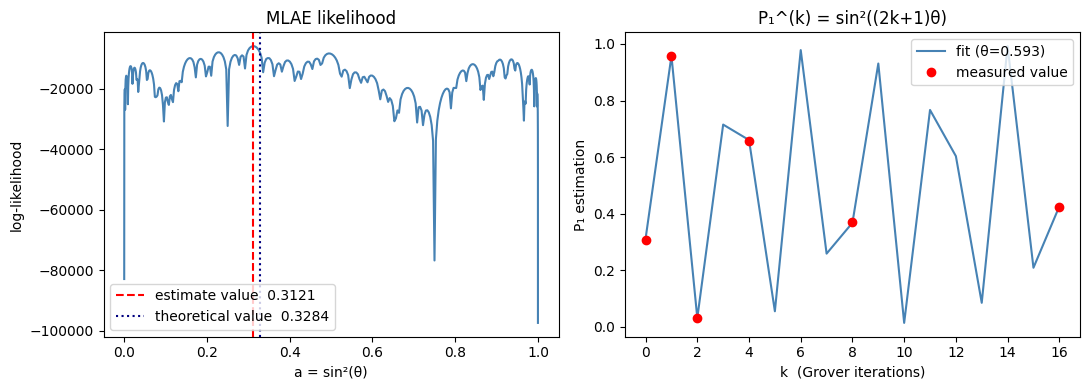

In [9]:
# ============================================================
# 5. 可視化
# ============================================================
theta_grid = np.linspace(1e-4, np.pi / 2 - 1e-4, 400)
ll_grid    = np.array([-neg_log_lik(t) for t in theta_grid])
a_grid     = np.sin(theta_grid)**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(a_grid, ll_grid, color='steelblue')
axes[0].axvline(a_hat,     color='red',  ls='--',
                label=f'estimate value  {a_hat:.4f}')
axes[0].axvline(P1_theory, color='navy', ls=':',
                label=f'theoretical value  {P1_theory:.4f}')
axes[0].set_xlabel('a = sin²(θ)')
axes[0].set_ylabel('log-likelihood')
axes[0].set_title('MLAE likelihood')
axes[0].legend()

k_dense      = np.arange(max(k_list) + 1)
P1_fit_dense = np.sin((2 * k_dense + 1) * theta_hat)**2
axes[1].plot(k_dense, P1_fit_dense, '-', color='steelblue',
             label=f'fit (θ={theta_hat:.3f})')
axes[1].plot(k_list, [h / N for h, N in zip(h_list, N_list)],
             'o', color='red', zorder=5, label='measured value')
axes[1].set_xlabel('k  (Grover iterations)')
axes[1].set_ylabel('P₁ estimation')
axes[1].set_title('P₁^(k) = sin²((2k+1)θ)')
axes[1].legend()

plt.tight_layout()
plt.show()

今回の実装が、理論値に近い結果を得られていることがわかります。